In [1]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/Users/mrenke/data/ds-stressrisk'
plot_folder_path = '/Users/mrenke/Desktop/StressRisk/figures/plots/paper'

sns.set_context('talk')
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')


In [2]:
from stress_risk.behavior.utils import get_data
df = get_data()
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df_comb_shifts = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/r-prior-shift_Ediff_AUC.csv')

df.join(df_comb_shifts.set_index('subject')['AUC'], on='subject', how='left')

session        rt    n1    n2  prob1  prob2  choice  \
subject run trial_nr                                                        
1       1   1               1  0.476974  13.0  10.0   0.55    1.0    True   
            2               1  0.505059   8.0   7.0   0.55    1.0    True   
            3               1  0.609260  13.0   7.0   0.55    1.0   False   
            4               1  0.522144  38.0  28.0   0.55    1.0    True   
            5               1  0.608297  16.0  10.0   0.55    1.0   False   
...                       ...       ...   ...   ...    ...    ...     ...   
61      6   116             2  1.189453  39.0  14.0   0.55    1.0   False   
            117             2  0.755411  43.0  20.0   0.55    1.0   False   
            118             2  0.905503  34.0  14.0   0.55    1.0    True   
            119             2  1.873285  34.0  20.0   0.55    1.0    True   
            120             2  0.989251  42.0  28.0   0.55    1.0    True   

                      risky_first  chose_risky  n_risky  n_safe      frac  \
subject run trial_nr                                                        
1       1   1                True        False     13.0    10.0  1.300000   
            2                True        False      8.0     7.0  1.142857   
            3                True         True     13.0     7.0  1.857143   
            4                True        False     38.0    28.0  1.357143   
            5                True         True     16.0    10.0  1.600000   
...                           ...          ...      ...     ...       ...   
61      6   116              True         True     39.0    14.0  2.785714   
            117              True         True     43.0    20.0  2.150000   
            118              True        False     34.0    14.0  2.428571   
            119              True        False     34.0    20.0  1.700000   
            120              True        False     42.0    28.0  1.500000   

                      log(risky/safe)   log(n1) bin(risky/safe)    p1   p2  \
subject run trial_nr                                                         
1       1   1                0.262364  2.564949             32%  0.55  1.0   
            2                0.133531  2.079442             20%  0.55  1.0   
            3                0.619039  2.564949             56%  0.55  1.0   
            4                0.305382  3.637586             32%  0.55  1.0   
            5                0.470004  2.772589             44%  0.55  1.0   
...                               ...       ...             ...   ...  ...   
61      6   116              1.024504  3.663562             80%  0.55  1.0   
            117              0.765468  3.761200             56%  0.55  1.0   
            118              0.887303  3.526361             68%  0.55  1.0   
            119              0.530628  3.526361             32%  0.55  1.0   
            120              0.405465  3.737670             20%  0.55  1.0   

                      group   AUC  
subject run trial_nr               
1       1   1           0.0  2.06  
            2           0.0  2.06  
            3           0.0  2.06  
            4           0.0  2.06  
            5           0.0  2.06  
...                     ...   ...  
61      6   116         0.0  2.11  
            117         0.0  2.11  
            118         0.0  2.11  
            119         0.0  2.11  
            120         0.0  2.11  

[11891 rows x 19 columns]

## Probit model

### RNP & psychometric curve illustration

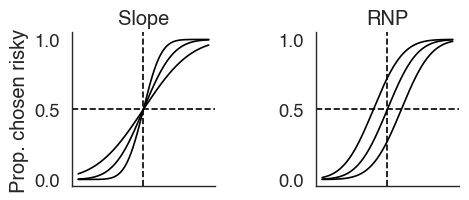

In [76]:
import scipy.stats as ss

sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')

x = np.linspace(-.8, 2, 500)
mu_rn = np.log(1/0.55)
fig, axs = plt.subplots(1, 2, figsize=(5,2))

for sd in [.3, .5, .8]:
    d = ss.norm(mu_rn, sd)
    axs[0].plot(x, d.cdf(x), color='k')

for mu in [ mu_rn - 0.3, mu_rn, mu_rn + 0.3]:
    d = ss.norm(mu, .5)
    axs[1].plot(x, d.cdf(x), color='k')

for ax in axs:
    ax.axvline(mu_rn, color='k', linestyle='--')
    ax.axhline(0.5, color='k', linestyle='--')
    ax.set(xticks=[], ylabel='Prop. chosen risky', yticks=[0.0, 0.5, 1.0])

axs[0].set(title='Slope',)
axs[1].set(ylabel=None, title='RNP')   
fig.subplots_adjust(wspace = 0.7) # adjust vertical space between axes
#fig.suptitle('prop. chosen risky', y=0.5, x=0,rotation='vertical', va='center')

sns.despine()
plt.savefig(op.join(plot_folder_path, f'probit-model_illustration_01.pdf'), bbox_inches='tight')


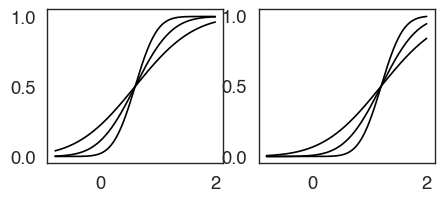

In [78]:
fig, axs = plt.subplots(1, 2, figsize=(5,2))

mu_rn = np.log(1/0.55)
for sd in [.3, .5, .8]:
    d = ss.norm(mu_rn, sd)
    axs[0].plot(x, d.cdf(x), color='k')

mu_rn = np.log(1/0.3)
for sd in [.3, .5, .8]:
    d = ss.norm(mu_rn, sd)
    axs[1].plot(x, d.cdf(x), color='k')

### Posterior distributions
statistical values for paper from >behavor/probit-mode_fit&posPlot.ipynb<

In [22]:
probit_params = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/probit-1_pposterior_params.csv')
probit_params.set_index(['param','subject','session','group','risky_first','n_safe'], inplace=True)
probit_params.drop('Unnamed: 0', axis=1, inplace=True)
probit_params.rename(columns={'chose_risky_mean':'chose_risky_mean.0'}, inplace=True)
color = 'grey'
probit_params.head()

# rename columns to multiindex (draw, chose_risky_mean)
split_columns = probit_params.columns.str.split('.', expand=True)
probit_params.columns = pd.MultiIndex.from_tuples(split_columns)
#probit_params.head()

In [23]:
dd = probit_params.xs(2,0,'session') - probit_params.xs(1,0,'session')
dd.drop('intercept', axis=0, inplace=True)
dd = dd.stack().rename(mapper={'chose_risky_mean':'y'},axis=1).reset_index('group')
dd['group'] = dd['group'].replace({0: 'control', 1: 'stress'})
#dd.head()

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_1191/1466083609.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dd.drop('intercept', axis=0, inplace=True)


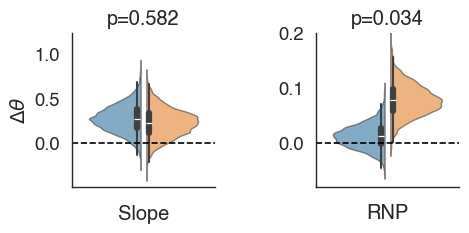

In [73]:
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')

params = ['gamma', 'rnp']

fig, axs = plt.subplots(1,2, figsize=(5,2)) #2.5, 1

for ax, param in zip(axs, params):
    sns.violinplot(dd.xs(param,0,'param').reset_index(),y='y', hue='group',split=True,legend=False,gap=.1,alpha=.6, ax=ax) # x='param',
    ax.axhline(0, c='k', ls='--')
    ymin, ymax = ax.get_ylim()
    new_ymax = np.abs(ymin) * 2.5
    pval = get_diffindiff_pval(probit_params, param)
    ax.set(ylim=[ymin, new_ymax], ylabel=None, title=f'p={pval}')
sns.despine()

axs[0].set(ylabel=r'$\Delta\theta$', xlabel='Slope')
axs[1].set(ylabel=None, xlabel='RNP', yticks=[0,0.1,0.2])   

#axs[0].plot([-0.25,-0.25,0.25,0.25], [0.5, 1.2, 1.2 ,  0.45], lw=2, color='grey') 
#axs[1].plot([-0.25,-0.25,0.25,0.25], [ 0.05, 0.2,0.2,  0.13], lw=2, color='grey') 

fig.subplots_adjust(wspace = 0.7) # adjust horizontal space between axes
plt.savefig(op.join(plot_folder_path, f'probit-model_diffinsessions_violin.pdf'), bbox_inches='tight')


### posterior predictive checks


In [51]:
from stress_risk.behavior.utils import get_data, summarize_ppc, plot_prediction, format_bambi_ppc
import bambi
import arviz as az

df = get_data()
df['x'] = df['log(risky/safe)']
df['log(risky/safe)'] = df['bin(risky/safe)']

formulae = 'chose_risky ~ x*session*group + (x*session|subject)'
model = bambi.Model(formulae, link='probit', family='bernoulli', data=df.reset_index())
traces= az.from_netcdf(op.join(bids_folder,'derivatives', 'cogmodels' , f'bambi-RNP-fit_trace_model1.netcdf'))

groupby = ['log(risky/safe)', 'session','group']
ppc = format_bambi_ppc(traces, model, df)
ppc = ppc.xs('ll_bernoulli', 0 , 'variable') # instead of 'p', makes the hdi wider
ppc = ppc.reset_index('log(risky/safe)')
ppc['log(risky/safe)'] = ppc.index.get_level_values('bin(risky/safe)')

ppc = ppc.groupby(['subject']+groupby).mean()

ppc_summary = summarize_ppc(ppc, groupby=groupby)
df_summary = df.groupby(groupby)[['chose_risky']].mean()

ppc_summary = ppc_summary.join(df_summary).reset_index()
ppc_summary['prop. chosen risky'] = ppc_summary['chose_risky']
ppc_summary['Predicted acceptance'] = ppc_summary['log(risky/safe)']
ppc_summary['group'] = np.where(ppc_summary['group'] == 0, 'Control', 'Stress') # modify names of group

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_30375/1431247820.py:19: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ppc = ppc.groupby(['subject']+groupby).mean()
/Users/mrenke/git/stress_risk/stress_risk/behavior/utils.py:116: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,


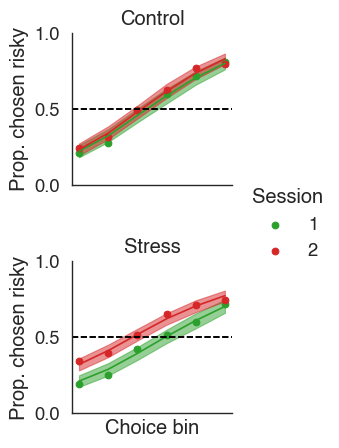

In [65]:
# Plotting
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')
x = 'Predicted acceptance'

#plt.figure(figsize=(5,2)) 
fac = sns.FacetGrid(ppc_summary,
                            hue='session',
                            row='group',
                            palette=sns.color_palette()[2:],
                            height=2.5, # height of each facet in inches --> fits size of figs above
                            aspect=1) # aspect ratio of each facet)

fac.map_dataframe(plot_prediction, x=x) # uses y='p_predicted'
fac.map(plt.scatter, x, 'prop. chosen risky')
fac.map(lambda *args, **kwargs: plt.axhline(.5, c='k', ls='--'))

fac.set_titles('{row_name}')
fac.set(xlabel='Choice bin', ylabel='Prop. chosen risky', xticks=[],yticks=[0.0, 0.5, 1.0]) # for poster
fac.add_legend(title='Session')

fac.fig.subplots_adjust(hspace = 0.5) # adjust horizontal space between axes
fac.fig.set_size_inches(4,5)

plt.savefig(op.join(plot_folder_path, f'probit-1_ppc.pdf'), bbox_inches='tight')

## NLC 

### model illustration

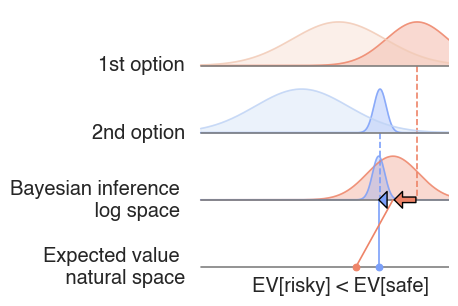

In [25]:
from utils import plot_bayesian_inference, annotat_bayesian_inference
import seaborn as sns 
import matplotlib.pyplot as plt
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')

plt.figure(figsize=(4,3.5))
plot_bayesian_inference(risky_first = True,base = 49)
annotat_bayesian_inference()
plt.savefig(op.join(plot_folder_path, f'NLC-model_illustration_01.pdf'), bbox_inches='tight')


### Results

In [81]:
params = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/probit-1_pposterior_params.csv')
#params.columns = params.columns.droplevel(params.columns[0])
params = params.drop('Unnamed: 0',axis=1)
params = params.set_index(['param','subject','session','group','risky_first','n_safe'])

params.head()

## just created plots in fi2_rnp 

chose_risky_mean  \
param subject session group risky_first n_safe                     
rnp   1       1       0.0   True        10.0            0.501135   
                                        7.0             0.501135   
                                        28.0            0.501135   
                                        14.0            0.501135   
                                        20.0            0.501135   

                                                chose_risky_mean.1  \
param subject session group risky_first n_safe                       
rnp   1       1       0.0   True        10.0              0.524781   
                                        7.0               0.524781   
                                        28.0              0.524781   
                                        14.0              0.524781   
                                        20.0              0.524781   

                                                chose_risky_mean.2  \
param subject session group risky_first n_safe                       
rnp   1       1       0.0   True        10.0              0.509993   
                                        7.0               0.509993   
                                        28.0              0.509993   
                                        14.0              0.509993   
                                        20.0              0.509993   

                                                chose_risky_mean.3  \
param subject session group risky_first n_safe                       
rnp   1       1       0.0   True        10.0                 0.549   
                                        7.0                  0.549   
                                        28.0                 0.549   
                                        14.0                 0.549   
                                        20.0                 0.549   

                                                chose_risky_mean.4  \
param subject session group risky_first n_safe                       
rnp   1       1       0.0   True        10.0              0.555853   
                                        7.0               0.555853   
                                        28.0              0.555853   
                                        14.0              0.555853   
                                        20.0              0.555853   

                                                chose_risky_mean.5  \
param subject session group risky_first n_safe                       
rnp   1       1       0.0   True        10.0              0.535292   
                                        7.0               0.535292   
                                        28.0              0.535292   
                                        14.0              0.535292   
                                        20.0              0.535292   

                                                chose_risky_mean.6  \
param subject session group risky_first n_safe                       
rnp   1       1       0.0   True        10.0              0.502861   
                                        7.0               0.502861   
                                        28.0              0.502861   
                                        14.0              0.502861   
                                        20.0              0.502861   

                                                chose_risky_mean.7  \
param subject session group risky_first n_safe                       
rnp   1       1       0.0   True        10.0              0.494759   
                                        7.0               0.494759   
                                        28.0              0.494759   
                                        14.0              0.494759   
                                        20.0              0.494759   

                                                chose_risky_mean.8  \
param subject session group risky_first n_safe                  

### NLC model

In [7]:
import arviz as az
from bauer.utils.math import softplus_np

idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-1_trace.netcdf'))

def get_posterior(idata,param,regressor):
    df = idata.posterior[param].to_dataframe()
    df.index = df.index.set_names(['chain','draw','subject','regressor'])
    df = df.xs(regressor, 0,'regressor')
    df['regressor'] = regressor
    return df

def get_post_diffindiff(idata,param):
    df_control_dif = get_posterior(idata,param,'session')
    df_stress_dif = get_posterior(idata,param,'session') + get_posterior(idata,param,'session:group')
    df_c = pd.concat((df_control_dif, df_stress_dif), axis=0)
    df_c = df_c.set_index('regressor', append=True)
    return df_c

params = ['safe_prior_mu','risky_prior_mu','safe_prior_std','risky_prior_std','n1_evidence_sd','n2_evidence_sd']


### diff between sessions

In [8]:
df_sp = get_post_diffindiff(idata,'safe_prior_mu')
df_rp = get_post_diffindiff(idata,'risky_prior_mu')
df_1e = get_post_diffindiff(idata,'n1_evidence_sd')
df_2e = get_post_diffindiff(idata,'n2_evidence_sd')

dd = pd.concat([df_rp,df_sp,df_1e,df_2e], axis=1)
dd = dd.stack().to_frame('value')
dd.index = dd.index.set_names(['chain','draw','subject','regressor','param'])
dd.index = dd.index.set_levels(['Control', 'Stress'], level='regressor')

dd.head()

value
chain draw subject regressor param                   
0     0    1       Control   risky_prior_mu  0.093866
                             safe_prior_mu  -0.118882
                             n1_evidence_sd -0.039612
                             n2_evidence_sd -0.205532
           2       Control   risky_prior_mu -0.066194

In [5]:
df_sp = get_posterior(idata,'safe_prior_mu','session:group').drop('regressor', axis=1)
df_rp = get_posterior(idata,'risky_prior_mu','session:group').drop('regressor', axis=1)
df_1e = get_posterior(idata,'n1_evidence_sd','session:group').drop('regressor', axis=1)
df_2e = get_posterior(idata,'n2_evidence_sd','session:group').drop('regressor', axis=1)

ddd = pd.concat([df_rp,df_sp, df_1e,df_2e], axis=1)


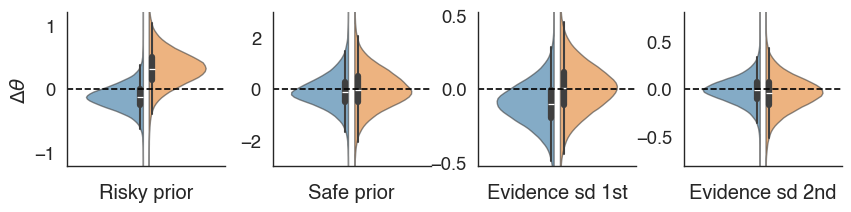

In [17]:
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')
split=True
params = dd.index.get_level_values('param').unique()
col_names = ['Risky prior','Safe prior','Evidence sd 1st','Evidence sd 2nd']
y_range_scaler = 0.5
fig, axs = plt.subplots(1,len(params), figsize=(10,2)) #2.5, 1

for ax, param,col_name in zip(axs, params,col_names):
    sns.violinplot(dd.xs(param,0,'param').reset_index(),y='value', hue='regressor',split=split,legend=False,gap=.1,alpha=.6, ax=ax) # x='param',
    ax.axhline(0, c='k', ls='--')
    ymin, ymax = ax.get_ylim()
    #new_ymax = np.abs(ymin) * 2.5
    ax.set(ylim=[-ymax*y_range_scaler, ymax*y_range_scaler], ylabel=None,xlabel=col_name)
sns.despine()
axs[0].set(ylabel=r'$\Delta\theta$')
fig.subplots_adjust(wspace = 0.4) # adjust horizontal space between axes
plt.savefig(op.join(plot_folder_path, f'NLC-post_stres-control_violin_spli-{split}.pdf'), bbox_inches='tight')

### diff in diff

In [9]:
df_sp = get_posterior(idata,'safe_prior_mu','session:group').drop('regressor', axis=1)
df_rp = get_posterior(idata,'risky_prior_mu','session:group').drop('regressor', axis=1)
df_1e = get_posterior(idata,'n1_evidence_sd','session:group').drop('regressor', axis=1)
df_2e = get_posterior(idata,'n2_evidence_sd','session:group').drop('regressor', axis=1)

dd = pd.concat([df_rp,df_sp, df_1e,df_2e], axis=1)

Risky prior: p=0.035505, mean=0.446140713932167, 95%CI=[-0.05575533  0.96203626]
Safe prior: p=0.43047, mean=0.09049309633438826, 95%CI=[-1.06882931  1.32122005]
Evidence sd 1st: p=0.20851, mean=0.10779788423925132, 95%CI=[-0.16209689  0.38529688]
Evidence sd 2nd: p=0.585515, mean=-0.03540236988471522, 95%CI=[-0.37329918  0.27867119]


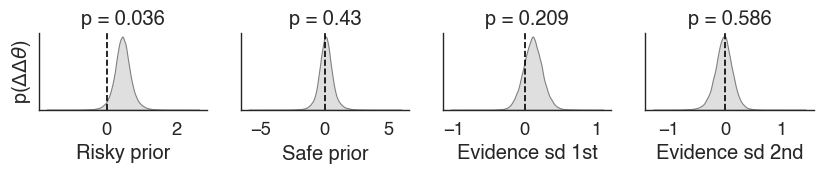

In [11]:
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')
fig, axs = plt.subplots(1,len(dd.columns), figsize=(10,1)) # 5*len(dd.columns)
col_names = ['Risky prior','Safe prior','Evidence sd 1st','Evidence sd 2nd']

for ax, column, col_name in zip(axs, dd.columns,col_names):
    sns.kdeplot(data=dd, x=column, fill=True, ax=ax, color='grey')
    
    ax.set_title(f'p = {np.round(np.mean(dd[column]<0),3)}')
    ax.set_xlabel(col_name.capitalize())
    ax.axvline(0, c='k', ls='--')
    ax.set(ylabel=None, yticks=[]) # xlabel=None, 
    print(f'{col_name}: p={np.mean(dd[column]<0)}, mean={np.mean(dd[column])}, 95%CI={np.percentile(dd[column], [2.5, 97.5])}')

axs[0].set_ylabel(r'p($\Delta\Delta\theta$)')
sns.despine()
#plt.tight_layout()
#plt.savefig(op.join(plot_folder_path, f'NLC-post_diffindiff_dist.pdf'), bbox_inches='tight')

### posterior predictive check

In [4]:
## posterior predictive check
from stress_risk.behavior.utils import build_model,format_bambi_ppc #, plot_ppc
import arviz as az

model_label = '1'
model = build_model(model_label, df)
model.build_estimation_model()

traces= az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-1_trace.netcdf'))


In [5]:
from stress_risk.behavior.utils import plot_ppc

ppc = model.ppc(trace=traces.sel(draw=slice(None, None, 10)), data=df)
ppc.loc[ppc.index.get_level_values('risky_first')] = 1 - ppc.loc[ppc.index.get_level_values('risky_first')]



Sampling: [ll_bernoulli]


/Users/mrenke/git/stress_risk/stress_risk/behavior/utils.py:197: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ppc = ppc.groupby(['subject']+groupby).mean()
/Users/mrenke/git/stress_risk/stress_risk/behavior/utils.py:139: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,


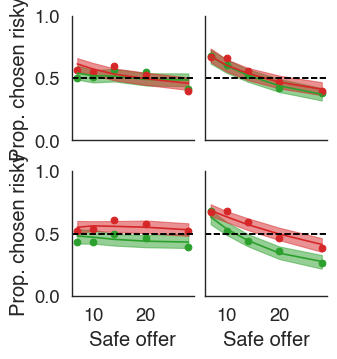

In [80]:
fac = plot_ppc(df, ppc, level='group', plot_type=6, var_name='ll_bernoulli', col_wrap=5)

fac.fig.set_size_inches(3.5,3.5)
for legend in fac.fig.legends:
    legend.remove()

fac.axes[0,0].set(ylabel='Prop. chosen risky', yticks=[0,0.5,1],title='')
fac.axes[1,0].set(ylabel='Prop. chosen risky', yticks=[0,0.5,1],title='')
fac.axes[0,1].set(title='')
fac.axes[1,1].set(title='')
#fac.fig.subplots_adjust(hspace = 0.5) # adjust horizontal space between axes

plt.savefig(op.join(plot_folder_path, f'NLC-ppc_.pdf'), bbox_inches='tight')


## Decoding

In [3]:
# E_diff
Es_within = pd.read_csv(op.join(bids_folder, 'interim_sum_data', 'within_ses_decodedE.csv'))
Es_across = pd.read_csv(op.join(bids_folder, 'interim_sum_data','across_ses_decodedE.csv'))

Es_within = Es_within.set_index(['subject', 'trial_nr', 'session']).rename(mapper={'E':'E_w', 'sd':'sd_w'}, axis=1).xs(2,0,'session')
Es_across = Es_across.set_index(['subject', 'trial_nr']).rename(mapper={'E':'E_a', 'sd':'sd_a'}, axis=1)

from stress_risk.utils.data import add_cond2df
Es = Es_within.join(Es_across).set_index('risky_first', append=True)
Es = add_cond2df(Es)
Es['E_dif'] = Es['E_a'] - Es['E_w']

  Source  ddof1  ddof2         F     p-unc       np2
0  group      1     47  10.71497  0.001997  0.185653
               T        dof alternative     p-val           CI95%   cohen-d  \
T-test -3.257595  43.754409   two-sided  0.002175  [-0.21, -0.05]  0.935444   

          BF10     power  
T-test  16.965  0.893586  


49

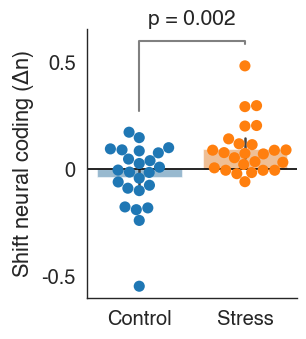

In [11]:
import pingouin
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.636, palette='tab10') # 1.636 = 1.5 * 14.4/13.2 (13.2 = font sizes in affinity designer with font scale 1.5)

temp = Es.groupby(['subject']).mean()
temp['group_name'] = np.where(temp['group'] == 0, 'Control', 'Stress')

plt.figure(figsize=(2.7,3.5)) 
ax = sns.barplot(data=temp.reset_index(), x ='group_name', hue='group_name',y='E_dif', alpha=0.5)
sns.swarmplot(data=temp.reset_index(), x='group_name', hue='group_name', y='E_dif', size=8)

an = pingouin.anova(data=temp.reset_index(), dv='E_dif', between='group')
p_val = np.round(an['p-unc'][0],3)

ax.set(xlabel=None, ylabel = r'Shift neural coding ($\Delta$n)') #title=f'p = {p_val}'
ax.text(0.5, 1, f'p = {p_val}', transform=ax.transAxes, ha='center', va='bottom',fontsize=15)

y_max_control= temp[temp['group_name'] == 'Control']['E_dif'].max()
y_max_stress= temp[temp['group_name'] == 'Stress']['E_dif'].max()
plt.plot([0., 0.,1 , 1], [y_max_control + 0.1, 0.6, 0.6, y_max_stress + 0.1], lw=1.5, color='grey')
plt.yticks([0.5, 0, -0.5], ['0.5', '0', '-0.5'])

plt.axhline(0, c='black')
sns.despine()
#plt.savefig(op.join(plot_folder_path, 'shift-neural-coding_swarm-bar-plot_groups.pdf'), bbox_inches='tight')
print(an)
temp.set_index('group_name', append=True,inplace=True)
ttest = pingouin.ttest(temp.xs('Control',0,'group_name')['E_dif'], temp.xs('Stress',0,'group_name')['E_dif']) # doch einen 2sample ttest machen
print(ttest)
len(temp.reset_index()['subject'].unique())

In [ ]:
# outlier removed
max_val = temp['E_dif'].max()
min_val = temp['E_dif'].min()
filtered_temp = temp[(temp['E_dif'] != max_val) & (temp['E_dif'] != min_val)]

#sns.catplot(data=filtered_temp.reset_index(), x='group_name', y='E_dif',  kind='swarm') #kind='bar',,errorbar=get_hdi

sns.barplot(data=filtered_temp.reset_index(), x='group_name',hue='group_name', y='E_dif', alpha=0.5)
sns.swarmplot(data=filtered_temp.reset_index(), x='group_name', hue='group_name',y='E_dif', size=8)

plt.xlabel(None)
plt.ylabel('shift neural coding')
an = pingouin.anova(data=filtered_temp.reset_index(), dv='E_dif', between='group')
p_val = np.round(an['p-unc'][0],3)
plt.title(f'p = {p_val}')
plt.axhline(0, c='black')

### Neural uncertainity

In [12]:
df_wdec = pd.read_csv(op.join(bids_folder, 'interim_sum_data','within-ses-decod_r-sds.csv'))
df_wdec = df_wdec.set_index(['group','subject','session'])

dd = df_wdec.xs(1,0,'session') - df_wdec.xs(2,0,'session')
dd.reset_index(inplace=True)
dd['group'] = dd['group'].str.capitalize()
dd.set_index('group', inplace=True)


  Source  ddof1  ddof2         F     p-unc      np2
0  group      1     47  0.873718  0.354706  0.01825
              T        dof alternative    p-val          CI95%   cohen-d  \
T-test -0.93506  46.971353   two-sided  0.35454  [-0.12, 0.05]  0.267121   

         BF10     power  
T-test  0.407  0.150204  


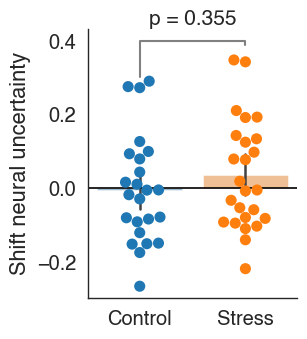

In [15]:
import pingouin
from matplotlib.ticker import FormatStrFormatter
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.636,palette='tab10')
y_var = 'r'

plt.figure(figsize=(2.7,3.5)) 
ax = sns.barplot(data=dd.reset_index(), x='group',hue='group', y=y_var, alpha=0.5)
sns.swarmplot(ax=ax,data=dd.reset_index(), x='group',hue='group', y=y_var,size=8)

an = pingouin.anova(data=dd.reset_index(), dv=y_var, between='group')
p_val = np.round(an['p-unc'][0],3)

ax.set(xlabel=None, ylabel = 'Shift neural uncertainty',title='') # ,title=f'p = {p_val}'; 'n.s.'
ax.text(0.5, 1, f'p = {p_val}', transform=ax.transAxes, ha='center', va='bottom',fontsize=15)

plt.axhline(0, c='black')
sns.despine()

temp = dd.reset_index()
height = 0.5
#ax.text(0.5, 1, 'n.s.', transform=ax.transAxes, ha='center', va='bottom',fontsize=25)

y_max_control= temp[temp['group'] == 'Control'][y_var].max()
y_max_stress= temp[temp['group'] == 'Stress'][y_var].max()
plt.plot([0., 0.,1 , 1], [y_max_control + 0.01, height-0.1, height-0.1, y_max_stress + 0.04], lw=1.5, color='grey')
#plt.yticks([0.5, 0, -0.5], ['0.5', '0', '-0.5'])

#plt.savefig(op.join(plot_folder_path, 'shift_decodability-r_catplot-groups.pdf'), bbox_inches='tight')
print(an)
temp.set_index(['group','subject'], inplace=True)
ttest = pingouin.ttest(temp.xs('Control',0,'group')[y_var], temp.xs('Stress',0,'group')[y_var]) # doch einen 2sample ttest machen
print(ttest)

In [17]:
len(temp['subject'].unique())

50

# Behav - Neural - corr.
### stress-effect: shift-prior/rnp with E-diff

In [72]:
import pingouin
# load in data frame from behavior/shifts_decode-priors.ipynb
df_comb_shifts = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/r-prior-shift_Ediff_AUC.csv')

df_probit_params = pd.read_csv(f'/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/param_estimates/bambi-1_subseswise_params.csv')
df_probit_params.set_index(['subject','session']).unstack('session',)['rnp']
df_rnp_shift = df_probit_params.set_index(['subject','session']).unstack('session',)['rnp']
df_rnp_shift = (df_rnp_shift[2] - df_rnp_shift[1]).to_frame()
df_rnp_shift = df_rnp_shift.rename(mapper={0:'rnp_shift'},axis=1)

df_comb_shifts = df_comb_shifts.join(df_rnp_shift, on='subject', how='left')
df_comb_shifts.head()

,subject,group,risky_prior_mu,AUC,E_dif,rnp_shift
0,1,0.0,-0.059489,2.060,NaN,-0.000149
1,2,0.0,-0.037181,-0.505,0.010657,0.138328
2,5,0.0,-0.057227,-0.635,-0.012330,0.059377
3,9,0.0,-0.275947,-1.595,0.041127,-0.055863
4,10,0.0,-0.171761,0.700,0.101818,-0.016770


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.4.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


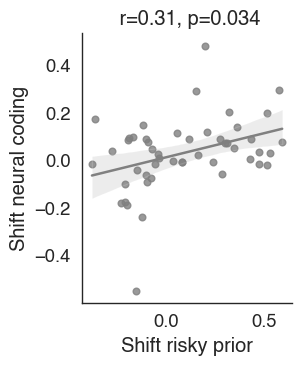

In [2]:

sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')

name_prior = 'risky_prior'
method = 'shepherd' # = robust, N-outliers = 2

temp = df_comb_shifts

plt.figure(figsize=(2.7,3.5)) 
fac = sns.regplot(data=temp.reset_index() , y = 'E_dif',x= f'{name_prior}_mu',line_kws={'color': 'grey'}, scatter_kws={'color': 'grey'}) #, hue='group'

cor = pingouin.corr(temp['E_dif'], temp[f'{name_prior}_mu'], method='shepherd')
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)
outliers = cor['outliers'][0]

fac.set(xlabel='Shift risky prior',ylabel='Shift neural coding', title = f' r={r_}, p={p}') #  \n outliers= {outliers}
#plt.axhline(0, c='black', ls='--')
#plt.axvline(0, c='black', ls='--')

sns.despine()
plt.savefig(op.join(plot_folder_path, 'shift-prior_E-diff_corr_robust.pdf'), bbox_inches='tight')# , bbox_inches='tight'

In [5]:
# mediation anaylis

pingouin.mediation_analysis(df_comb_shifts,x='group',m='risky_prior_mu',y='E_dif')
pingouin.mediation_analysis(df_comb_shifts,x='group',y='risky_prior_mu',m='E_dif')

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,risky_prior_mu ~ X,0.469755,0.038926,5.304504e-16,0.391445,0.548064,Yes
1,Y ~ risky_prior_mu,0.203218,0.076216,1.048118e-02,0.049892,0.356545,Yes
2,Total,0.130509,0.039870,1.997354e-03,0.050301,0.210717,Yes
3,Direct,0.143639,0.081558,8.485434e-02,-0.020530,0.307808,No
4,Indirect,-0.013130,0.060600,8.240000e-01,-0.148688,0.089043,No


[Text(0.5, 0, 'Shift RNP'),
 Text(0, 0.5, 'Shift neural coding'),
 Text(0.5, 1.0, ' r=-0.0, p=0.975')]

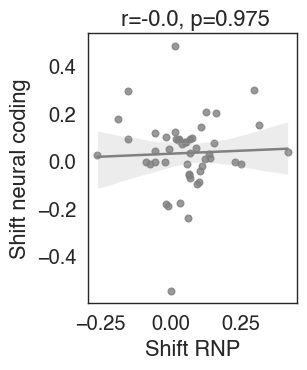

In [75]:
name_prior = 'rnp_shift'
temp = df_comb_shifts#.set_index(['subject','group']).xs(0,0,'group')

plt.figure(figsize=(2.7,3.5)) 
fac = sns.regplot(data=temp.reset_index() , y = 'E_dif',x= f'{name_prior}',line_kws={'color': 'grey'}, scatter_kws={'color': 'grey'}) #, hue='group'
cor = pingouin.corr(temp['E_dif'], temp[f'{name_prior}'], method='shepherd')
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)
outliers = cor['outliers'][0]

fac.set(xlabel='Shift RNP',ylabel='Shift neural coding', title = f' r={r_}, p={p}') #  \n outliers= {outliers}


In [81]:
1-0.963


0.03700000000000003